In [1]:
"""Sionna RT 2.0 → DeepMIMO: Run, Export, Convert."""

'Sionna RT 2.0 → DeepMIMO: Run, Export, Convert.'

# Sionna RT 2.0 → DeepMIMO: Run, Export, Convert

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepMIMO/DeepMIMO/blob/main/docs/applications/2_sionna_rt_downstream.py)
&nbsp;
[![GitHub](https://img.shields.io/badge/Open_on-GitHub-181717?logo=github&style=for-the-badge)](https://github.com/DeepMIMO/DeepMIMO/blob/main/docs/applications/2_sionna_rt_downstream.py)

---

**What this notebook covers:**
1. Load Sionna RT 2.0's built-in Munich scene and visualize it
2. Run specular-reflection ray tracing with timing
3. Inspect propagation paths directly from Sionna
4. Export results to disk with DeepMIMO's `sionna_exporter`
5. Convert to a DeepMIMO scenario with `dm.convert`
6. Explore channels: delay profiles and ray visualization

**Why this workflow?**
Sionna RT does not natively persist ray tracing results to disk.
DeepMIMO's exporter serializes all path data (delays, angles, vertices,
interaction types) so expensive simulations can be reused without re-running
the ray tracer. The converter maps that data into the standardized DeepMIMO
format, unlocking the full DeepMIMO toolchain.

**Requirements:**
```bash
pip install 'deepmimo[sionna]'
```

---

In [2]:
%pip install 'deepmimo[sionna]'  # uncomment if not installed

/home/joao/DeepMIMO/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


## Imports

In [3]:
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sionna.rt as sionna_rt
from sionna.rt import Camera, PathSolver, PlanarArray, Receiver, Transmitter

import deepmimo as dm
from deepmimo.exporters.sionna_exporter import sionna_exporter

## Scene Configuration

We use Sionna's built-in **Munich** scene: a realistic urban environment
with buildings, streets, and varied geometry. The transmitter is placed
on a rooftop; receivers are placed at street level.

We use `max_depth=3` with specular reflections, diffuse scattering, and edge
diffraction (UTD around building corners and rooftop edges).  Together these
capture LoS, multi-bounce specular, dense scattered multipath, and the
classic NLOS corner-diffraction paths that bend around obstacles.

In [4]:
CARRIER_FREQ = 3.5e9  # 3.5 GHz

# Ray-tracing parameters forwarded to PathSolver
RT_PARAMS = {
    "max_depth": 3,  # LoS + up to 3 interactions (reflect / diffract)
    "los": True,
    "specular_reflection": True,
    "diffuse_reflection": True,  # Lambertian surface scattering
    "diffraction": True,  # UTD edge diffraction around building corners
    "refraction": False,
    "samples_per_src": 2_000_000,
}

# Transmitter — rooftop position
TX_POS = [-210.0, 73.0, 105.0]

# Receivers — four street-level positions with confirmed propagation paths
RX_POSITIONS = [
    [40.0, 20.0, 1.5],
    [20.0, 50.0, 1.5],
    [30.0, 60.0, 1.5],
    [50.0, 50.0, 1.5],
]

## Build the Scene

In [5]:
_t0 = time.perf_counter()

scene = sionna_rt.load_scene(sionna_rt.scene.munich)
scene.frequency = CARRIER_FREQ

# Single-element isotropic antenna at TX and RX
single_ant = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)
scene.tx_array = single_ant
scene.rx_array = single_ant

# Add transmitter
tx = Transmitter("tx_0", position=TX_POS)
tx.display_radius = 5.0  # metres; default heuristic is too large for Munich
scene.add(tx)

# Add receivers
for i, pos in enumerate(RX_POSITIONS):
    rx = Receiver(f"rx_{i}", position=pos)
    rx.display_radius = 4.0  # metres
    scene.add(rx)

t_scene = time.perf_counter() - _t0
print(f"TX position : {TX_POS}")
print(f"RX count    : {len(RX_POSITIONS)}")
print(f"Scene load  : {t_scene:.2f} s")

TX position : [-210.0, 73.0, 105.0]
RX count    : 4
Scene load  : 0.36 s


## Visualize the Scene

Sionna RT renders the 3D scene with device positions before any ray tracing.
The top-down view shows the full Munich scene geometry; the oblique view gives
a sense of building heights relative to the rooftop TX.

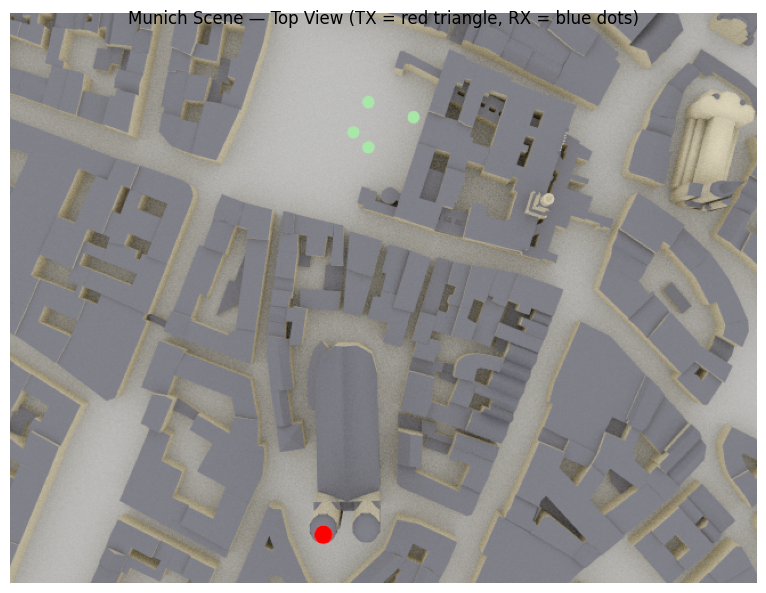

In [6]:
# Top-down view centered between TX and receiver cluster
cam_top = Camera(position=[-80.0, 40.0, 600.0], look_at=[-80.0, 40.0, 0.0])
fig = scene.render(camera=cam_top, show_devices=True)
fig.suptitle("Munich Scene — Top View (TX = red triangle, RX = blue dots)")
plt.show()

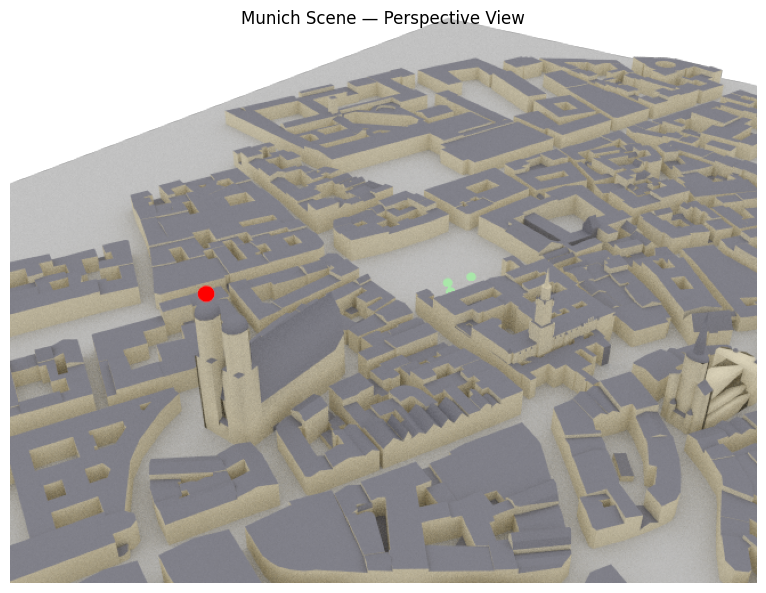

In [7]:
# Oblique perspective from the south-west
cam_oblique = Camera(position=[-500.0, -300.0, 400.0], look_at=[-80.0, 40.0, 50.0])
fig = scene.render(camera=cam_oblique, show_devices=True)
fig.suptitle("Munich Scene — Perspective View")
plt.show()

## Run Ray Tracing

In [8]:
p_solver = PathSolver()

_t = time.perf_counter()
paths = p_solver(scene=scene, **RT_PARAMS)
t_rt = time.perf_counter() - _t

n_rx = paths.tau.shape[0]
n_tx = paths.tau.shape[1]
max_paths = paths.tau.shape[2]

print(f"Ray tracing   : {t_rt:.1f} s")
print(f"Receivers     : {n_rx}")
print(f"Transmitters  : {n_tx}")
print(f"Max paths/pair: {max_paths}")
print(f"a[0] shape    : {paths.a[0].shape}  (n_rx, n_tx, n_rx_ant, n_tx_ant, n_paths)")

Ray tracing   : 0.1 s
Receivers     : 4
Transmitters  : 1
Max paths/pair: 48
a[0] shape    : (4, 1, 1, 1, 48)  (n_rx, n_tx, n_rx_ant, n_tx_ant, n_paths)


## Visualize Propagation Paths

Render the scene with the computed ray paths overlaid.
Each colored line segment represents a propagation path from TX to RX.

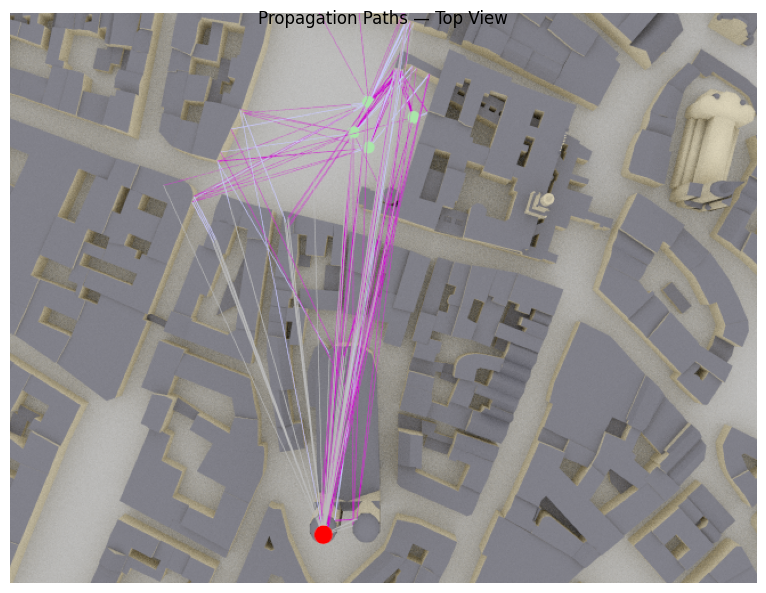

In [9]:
fig = scene.render(camera=cam_top, paths=paths, show_devices=True)
fig.suptitle("Propagation Paths — Top View")
plt.show()

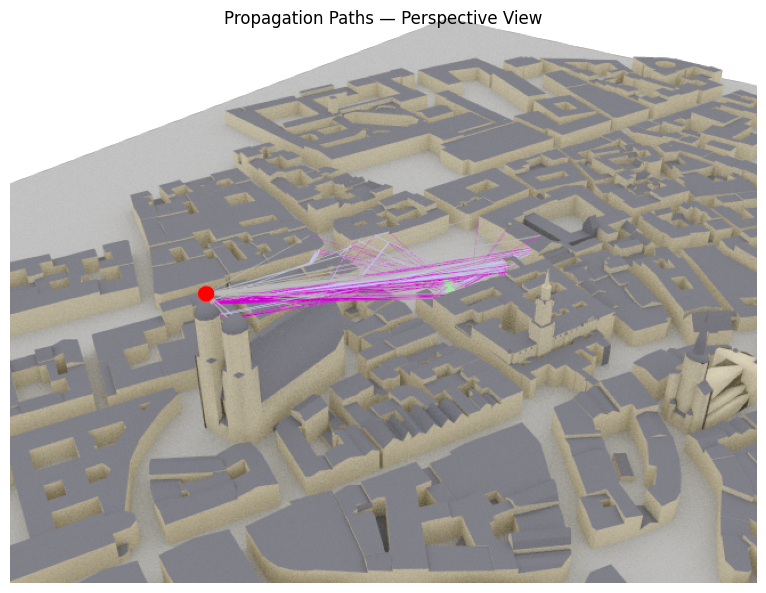

In [10]:
# Perspective view of paths
fig = scene.render(camera=cam_oblique, paths=paths, show_devices=True)
fig.suptitle("Propagation Paths — Perspective View")
plt.show()

## Power-Delay Profiles (Sionna)

Plot the per-receiver power-delay profile directly from the `Paths` object,
before any conversion.  Delays are in nanoseconds; power is derived from the
complex channel coefficient `a`.

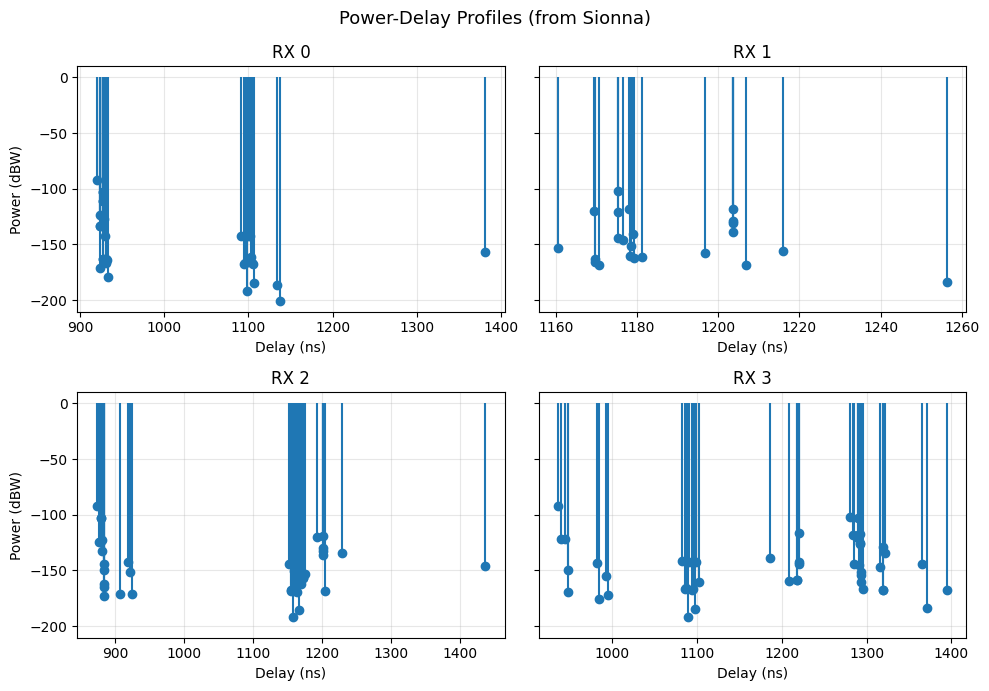

In [11]:
# Complex channel coefficients — shape: (n_rx, n_tx, n_rx_ant, n_tx_ant, max_paths)
a_complex = paths.a[0].numpy() + 1j * paths.a[1].numpy()
tau_np = paths.tau.numpy()  # (n_rx, n_tx, max_paths)

fig, axes = plt.subplots(2, (n_rx + 1) // 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()
for rx_idx in range(n_rx):
    ax = axes[rx_idx]
    delays_ns = tau_np[rx_idx, 0, :] * 1e9
    power_lin = np.abs(a_complex[rx_idx, 0, 0, 0, :]) ** 2
    valid = delays_ns > 0
    if valid.any():
        ax.stem(
            delays_ns[valid],
            10 * np.log10(power_lin[valid] + 1e-30),
            basefmt="none",
            markerfmt="C0o",
            linefmt="C0-",
        )
    ax.set_title(f"RX {rx_idx}")
    ax.set_xlabel("Delay (ns)")
    if rx_idx % ((n_rx + 1) // 2) == 0:
        ax.set_ylabel("Power (dBW)")
    ax.grid(visible=True, alpha=0.3)
for ax in axes[n_rx:]:
    ax.set_visible(False)

plt.suptitle("Power-Delay Profiles (from Sionna)", fontsize=13)
plt.tight_layout()
plt.show()

## Export with `sionna_exporter`

`sionna_exporter` serializes paths, materials, RT parameters, and full scene
geometry (vertices **and** face connectivity) into `.pkl` files.  Face
connectivity is used by the converter to split merged city meshes into
individual building components.

In [12]:
save_folder = str(Path(tempfile.mkdtemp()) / "munich_sionna_rt")

_t = time.perf_counter()
sionna_exporter(scene, paths, RT_PARAMS, save_folder)
t_export = time.perf_counter() - _t

print(f"Export        : {t_export:.2f} s  →  {save_folder}")
for f in sorted(Path(save_folder).iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:7.1f} KB")

Export        : 0.01 s  →  /tmp/tmpx4ssypfk/munich_sionna_rt
  sionna_faces.pkl                            456.4 KB
  sionna_material_indices.pkl                   0.2 KB
  sionna_materials.pkl                          1.1 KB
  sionna_objects.pkl                            0.3 KB
  sionna_paths.pkl                             14.9 KB
  sionna_rt_params.pkl                          0.6 KB
  sionna_vertices.pkl                         399.1 KB


## Convert to DeepMIMO Format

`dm.convert` auto-detects the Sionna `.pkl` files and routes them through
the Sionna RT converter, producing a scenario folder in the DeepMIMO
scenarios directory.

Determining converter...
Using Sionna RT converter
converting from sionna RT


Processing receivers for TX 0, Ant 0:   0%|          | 0/4 [00:00<?, ?it/s]

Processing receivers for TX 0, Ant 0: 100%|██████████| 4/4 [00:00<00:00, 2337.96it/s]

Convert       : 63.18 s  →  munich_sionna_rt


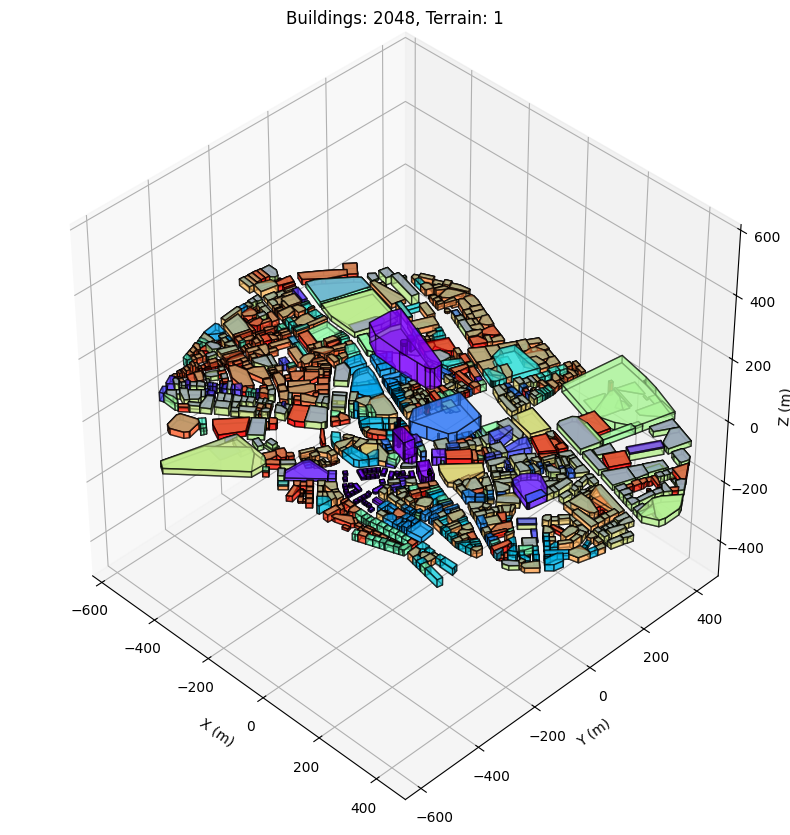

In [13]:
_t = time.perf_counter()
scenario_name = dm.convert(save_folder, overwrite=True)
t_convert = time.perf_counter() - _t
print(f"Convert       : {t_convert:.2f} s  →  {scenario_name}")

## Load and Inspect the DeepMIMO Dataset

In [14]:
_t = time.perf_counter()
dataset = dm.load(scenario_name)
t_load = time.perf_counter() - _t
print(dataset)
print(f"\nLoad          : {t_load:.2f} s")

Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 4)
{'aoa_az': array([[168.0305   , 167.93126  , 167.93126  , 167.93443  , 167.93443  ,
        168.0305   , 167.92096  , 168.19212  , 167.92882  , 167.5692   ,
         14.972552 ,  23.705832 ,  14.972552 , 106.40097  ,  14.972699 ,
        168.202    , 164.37828  ,  19.138586 , 167.55943  ,  19.138586 ,
         23.703562 , 164.4448   ,  19.137142 , -74.858315 ,  19.137144 ],
       [-20.969456 , -41.29406  , -20.969416 , -21.093536 , -20.971441 ,
        -41.29509  , -41.334812 , -41.177902 , 108.3206   , -22.651028 ,
        -25.263477 , -20.816635 ,  96.722984 ,  75.45665  ,  96.722984 ,
        -22.650774 , 106.81274  , -25.262482 , -19.320957 , -22.650774 ,
        -41.64541  , -25.262482 , -21.893612 ,         nan,         nan],
       [176.8995   , 176.85039  , 176.85039  , -43.632908 , -43.72962  ,
        176.84518  , 177.062    , 176.8995   , 176.36943  , -43.579906 ,
        -34.834766 , 176.85088  , -40.735344 , -23.

## Ray Visualization (DeepMIMO)

DeepMIMO stores the full 3D interaction geometry for each path.
`dataset.plot_rays` draws TX → bounce points → RX segments, color-coded by
interaction type (LoS = green, reflected = red), with the reconstructed scene
overlaid automatically.

The converter automatically deduplicates buildings that share multiple
material groups in the same physical space (e.g. concrete walls + glass
windows), so each building appears once.  Pass `deduplicate=False` to
`dm.convert` to disable this if needed.

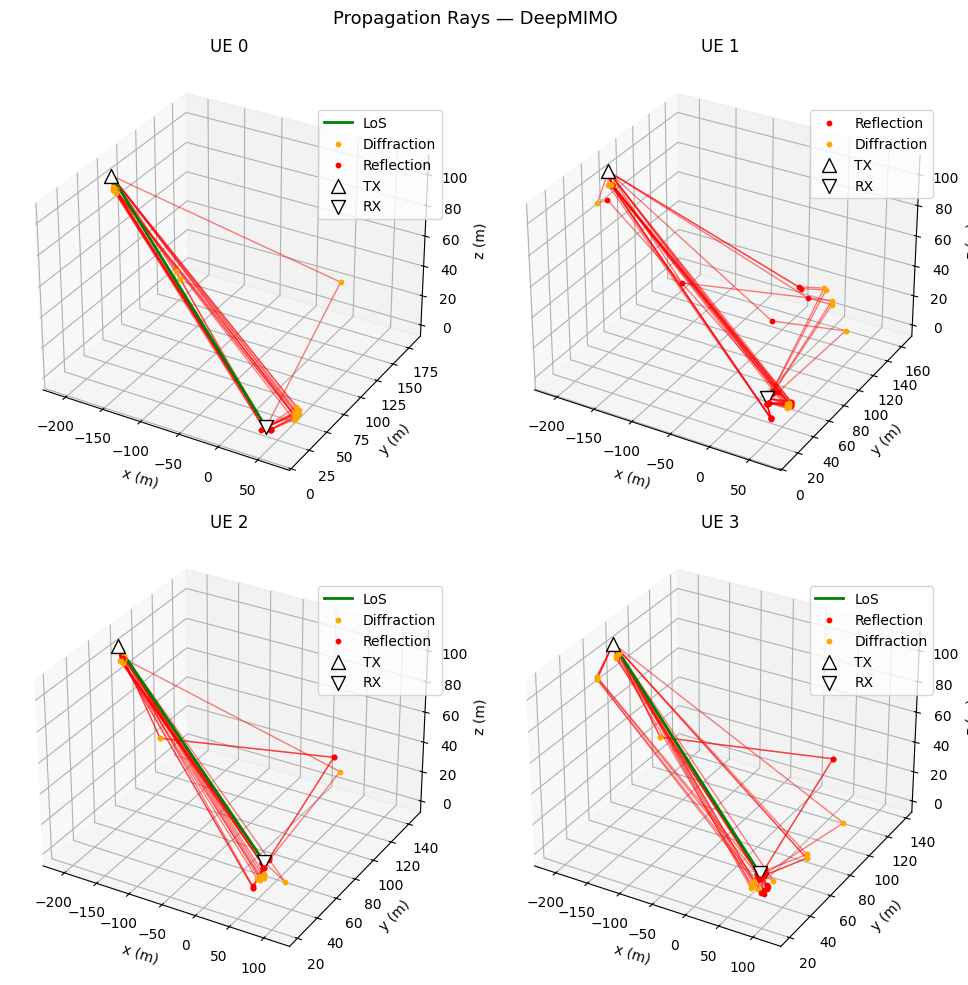

In [15]:
n_ue = len(dataset.rx_pos)
n_cols = min(n_ue, 2)
n_rows = (n_ue + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows), subplot_kw={"projection": "3d"})
axes = np.array(axes).flatten()
for u_idx in range(n_ue):
    dataset.plot_rays(u_idx, ax=axes[u_idx])
    axes[u_idx].set_title(f"UE {u_idx}")
for ax in axes[n_ue:]:
    ax.set_visible(False)
plt.suptitle("Propagation Rays — DeepMIMO", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

In [16]:
t_total = t_scene + t_rt + t_export + t_convert + t_load
rows = [
    ("Scene load", t_scene),
    ("Ray tracing", t_rt),
    ("Export", t_export),
    ("Convert", t_convert),
    ("Dataset load", t_load),
    ("─" * 14, None),
    ("Total", t_total),
]
print(f"{'Step':<16} {'Time':>8}")
print("─" * 26)
for label, val in rows:
    if val is None:
        print(f"{label}")
    else:
        print(f"{label:<16} {val:>7.2f} s")
print(
    f"\nRT params: max_depth={RT_PARAMS['max_depth']}, "
    f"diffraction={RT_PARAMS['diffraction']}, "
    f"diffuse={RT_PARAMS['diffuse_reflection']}, "
    f"samples={RT_PARAMS['samples_per_src']:,}"
)

Step                 Time
──────────────────────────
Scene load          0.36 s
Ray tracing         0.12 s
Export              0.01 s
Convert            63.18 s
Dataset load        0.14 s
──────────────
Total              63.81 s

RT params: max_depth=3, diffraction=True, diffuse=True, samples=2,000,000


The complete **Sionna RT 2.0 → DeepMIMO** pipeline:

| Step | Tool | Output |
|------|------|--------|
| 1. Load scene | `sionna_rt.load_scene` | `Scene` object |
| 2. Visualize | `scene.render` | RGBA renders |
| 3. Ray trace | `PathSolver` | `Paths` object |
| 4. Export | `sionna_exporter` | `.pkl` files on disk |
| 5. Convert | `dm.convert` | DeepMIMO scenario folder |
| 6. Load | `dm.load` | `Dataset` object |
| 7. Explore | `plot_rays`, delay profiles | Figures |

From here you can use any DeepMIMO tool: channel generation, beamforming,
dataset manipulation, Doppler, and ML training pipelines.